
# 04 CX Risk Segmentation v3

## Business Objective

This notebook identifies where customer experience risk is concentrated across:

- sellers
- product categories
- geographic delivery lanes

The objective is not only to rank operational performance.

The analysis converts delivery failures into:

1. risk concentration evidence
2. governance targets
3. service design opportunities

Business question:

**Where is CX risk concentrated, and where should operational intervention focus?**



# Analytical Logic

Reference projects commonly rank:

- sellers by delivery performance
- categories by delay rate
- regions by reliability metrics

This notebook extends that approach.

Instead of asking:

"Who has the worst metric?"

it asks:

"Which entities create the largest customer experience exposure?"

Framework:

Operational Risk
→ Late delivery probability

Customer Impact
→ Bad review relationship

Business Exposure
→ Order volume

Combined:

CX Risk Exposure =
Volume × Delivery Failure × Customer Dissatisfaction


In [47]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

seller_risk = pd.read_csv("../outputs/tables/seller_risk_table.csv")
category_risk = pd.read_csv("../outputs/tables/category_risk_table.csv")
region_risk = pd.read_csv("../outputs/tables/region_risk_table.csv")

seller_risk.head()


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/tables/seller_risk_table.csv'


# 1. Seller Risk Concentration

## Why

Seller-level ranking alone can over-emphasize small sellers.

A governance framework should identify sellers combining:

- meaningful order volume
- elevated delivery risk
- customer dissatisfaction impact


In [ ]:

seller_risk["cx_risk_score"] = (
    seller_risk["order_count"].rank(pct=True)
    *
    seller_risk["late_rate"].rank(pct=True)
    *
    seller_risk["bad_review_rate"].rank(pct=True)
)

seller_risk.sort_values(
    "cx_risk_score",
    ascending=False
).head(10)


,seller_id,order_count,late_rate,avg_delay_days,bad_review_rate,cx_exposure,risk_segment,cx_risk_score
323,1ca7077d890b907f89be8c954a02686a,108,0.166667,-6.666667,0.592593,10.666667,High volume high risk,0.805025
1928,a49928bcdf77c55c6d6e05e09a9b4ca5,96,0.218750,-4.447917,0.406250,8.531250,High volume high risk,0.796406
1000,54965bbe3e4f07ae045b90b0b8541f52,73,0.301370,-3.575342,0.383562,8.438356,High volume high risk,0.788421
1606,88460e8ebdecbfecb5f9601833981930,246,0.170732,-11.182927,0.304878,12.804878,High volume high risk,0.775316
1336,712e6ed8aa4aa1fa65dab41fed5737e4,77,0.207792,-9.116883,0.350649,5.610390,High volume high risk,0.765392
540,2eb70248d66e0e3ef83659f71b244378,187,0.112299,-10.053476,0.465241,9.770053,High volume high risk,0.750206
478,2a1348e9addc1af5aaa619b1a3679d6b,48,0.270833,0.979167,0.354167,4.604167,High volume high risk,0.740441
2171,bbad7e518d7af88a0897397ffdca1979,68,0.161765,-9.382353,0.397059,4.367647,High volume high risk,0.733095
2011,ad781527c93d00d89a11eecd9dcad7c1,38,0.315789,-9.078947,0.342105,4.105263,High volume high risk,0.717992
2365,cac4c8e7b1ca6252d8f20b2fc1a2e4af,74,0.175676,-6.756757,0.283784,3.689189,High volume high risk,0.707850


Who requires governance attention?

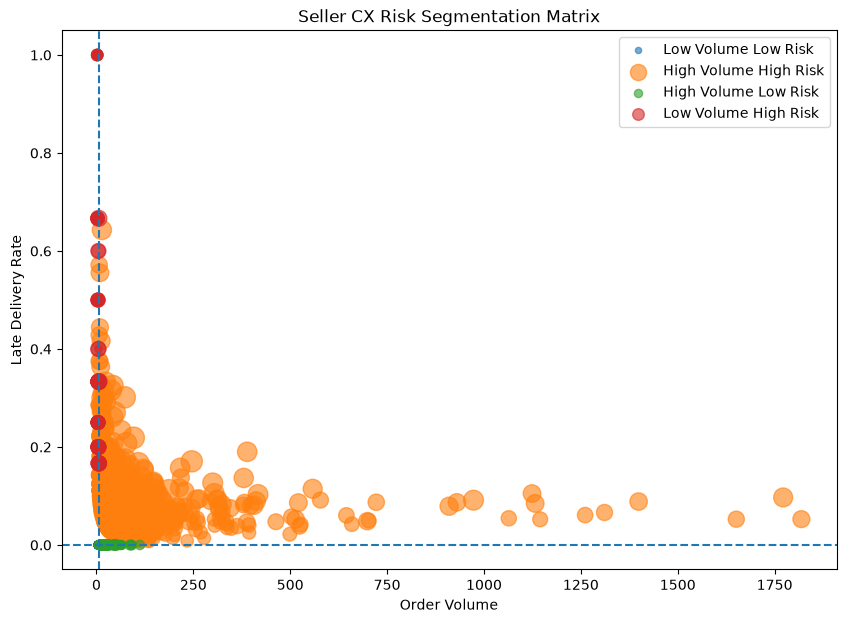

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


seller_plot = seller_risk.copy()


# percentile based segmentation

seller_plot["volume_percentile"] = (
    seller_plot["order_count"]
    .rank(pct=True)
)


seller_plot["risk_percentile"] = (
    seller_plot["late_rate"]
    .rank(pct=True)
)



def assign_segment(row):

    if (
        row["volume_percentile"] >=0.5
        and
        row["risk_percentile"] >=0.5
    ):
        return "High Volume High Risk"

    elif (
        row["volume_percentile"] >=0.5
        and
        row["risk_percentile"] <0.5
    ):
        return "High Volume Low Risk"

    elif (
        row["volume_percentile"] <0.5
        and
        row["risk_percentile"] >=0.5
    ):
        return "Low Volume High Risk"

    else:
        return "Low Volume Low Risk"



seller_plot["risk_group"] = (
    seller_plot.apply(
        assign_segment,
        axis=1
    )
)



plt.figure(figsize=(10,7))


for group in seller_plot["risk_group"].unique():

    temp = seller_plot[
        seller_plot["risk_group"]==group
    ]

    plt.scatter(
        temp["order_count"],
        temp["late_rate"],
        s=temp["cx_risk_score"]*300,
        alpha=0.6,
        label=group
    )



plt.axvline(
    seller_plot["order_count"].median(),
    linestyle="--"
)

plt.axhline(
    seller_plot["late_rate"].median(),
    linestyle="--"
)



plt.xlabel(
    "Order Volume"
)

plt.ylabel(
    "Late Delivery Rate"
)


plt.title(
    "Seller CX Risk Segmentation Matrix"
)


plt.legend()

plt.show()



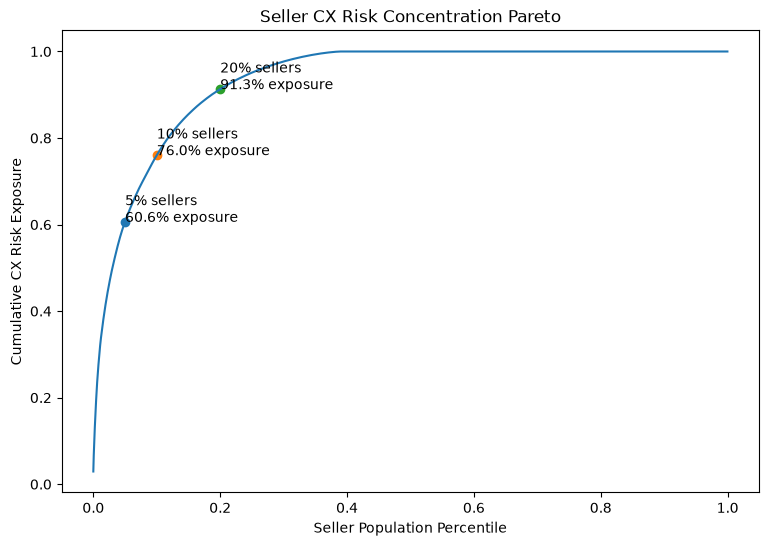

In [ ]:
seller_pareto = (
    seller_risk
    .sort_values(
        "cx_exposure",
        ascending=False
    )
    .reset_index(drop=True)
)


seller_pareto["seller_share"] = (
    np.arange(
        len(seller_pareto)
    )
    /
    len(seller_pareto)
)


seller_pareto["cumulative_exposure"] = (
    seller_pareto["cx_exposure"]
    .cumsum()
    /
    seller_pareto["cx_exposure"]
    .sum()
)



plt.figure(figsize=(9,6))


plt.plot(
    seller_pareto["seller_share"],
    seller_pareto["cumulative_exposure"]
)


# thresholds

for pct in [0.05,0.1,0.2]:

    value = (
        seller_pareto[
            seller_pareto["seller_share"]
            <=pct
        ]
        ["cumulative_exposure"]
        .max()
    )


    plt.scatter(
        pct,
        value
    )

    plt.text(
        pct,
        value,
        f"{pct*100:.0f}% sellers\n{value:.1%} exposure"
    )



plt.xlabel(
    "Seller Population Percentile"
)


plt.ylabel(
    "Cumulative CX Risk Exposure"
)


plt.title(
    "Seller CX Risk Concentration Pareto"
)


plt.show()


# Seller Risk Interpretation


## Objective

Translate seller-level risk segmentation into potential governance priorities.

The analysis focuses on identifying where customer experience exposure is concentrated,
rather than determining the root cause of delivery failures.


---

## Key Findings


### Seller Risk Segmentation

The seller risk matrix separates sellers into different operational profiles:

- High Volume High Risk:
  Sellers with large order exposure and elevated delivery failure rates.
  These sellers represent potential priority areas because operational issues may affect a larger customer population.


- Low Volume High Risk:
  Sellers showing high failure intensity but limited order exposure.
  These sellers may require investigation to determine whether issues are isolated events or recurring operational problems.


- High Volume Low Risk:
  Sellers with significant customer exposure but relatively stable delivery performance.
  These sellers represent important operational assets that require monitoring to maintain reliability.


- Low Volume Low Risk:
  Sellers with limited customer impact under the current dataset.


---

## Risk Concentration Analysis


The Pareto analysis shows that CX risk exposure is concentrated among a relatively small proportion of sellers.

Based on the current segmentation:

- Top 5% of sellers contribute approximately 60.6% of total CX risk exposure.
- Top 10% of sellers contribute approximately 76.0% of total CX risk exposure.
- Top 20% of sellers contribute approximately 91.3% of total CX risk exposure.


This indicates that customer experience risk is not evenly distributed across the seller population.

A targeted governance approach may therefore generate higher impact than broad seller-level intervention.


---

## Seller Governance Questions


The current analysis identifies where risk exposure is concentrated,
but additional investigation is required to understand why these sellers underperform.


Questions to investigate:

- Are high-risk sellers concentrated in specific product categories?
- Are delivery failures associated with seller operations or logistics constraints?
- Do high-risk sellers demonstrate repeated customer dissatisfaction patterns?


---

## Required Additional Data


The current dataset does not contain operational root-cause variables.

Additional data would improve diagnosis:

- carrier information
- fulfillment model
- seller SLA performance
- cancellation records
- customer support interactions
- shipment tracking events


Therefore, seller risk scores should be interpreted as governance prioritisation signals,
not direct evidence of seller-caused delivery failures.


# Governance Prioritisation Framework


## Objective

Translate risk segmentation results into
potential operational priorities.


## Seller Governance

Questions to investigate:

- Are high-risk sellers concentrated in specific categories?
- Are delivery failures caused by seller operations or logistics constraints?
- Do high-risk sellers have repeated customer dissatisfaction patterns?


Required additional data:

- carrier information
- fulfillment model
- seller SLA
- cancellation records
- customer support interactions



---

## Category Monitoring


Questions:

- Are high-risk categories affected by product characteristics?
- Are delays concentrated among specific sellers?
- Are customer expectations different across categories?


Required additional data:

- product size and weight
- delivery method
- return behaviour
- customer expectation data



---

## Service Reliability Planning


Questions:

- Are specific delivery lanes consistently underperforming?
- Are regional problems related to distance or logistics capacity?


Required additional data:

- shipping distance
- carrier performance
- delivery attempt history
- warehouse location



# 2. Category CX Exposure

## Why

A category with moderate delay rate may still create significant CX impact if order volume is large.

Therefore prioritisation considers exposure, not delay rate alone.


In [ ]:

category_risk["cx_risk_score"] = (
    category_risk["order_count"].rank(pct=True)
    *
    category_risk["late_rate"].rank(pct=True)
    *
    category_risk["bad_review_rate"].rank(pct=True)
)

category_risk.sort_values(
    "cx_risk_score",
    ascending=False
).head(10)


,product_category_clean,order_count,late_rate,avg_delay_days,bad_review_rate,avg_review_score,cx_exposure,cx_risk_score
7,bed_bath_table,9272,0.074310,-11.393658,0.158650,3.998910,109.309642,0.646457
57,office_furniture,1254,0.080542,-11.823764,0.217703,3.644695,21.988038,0.646062
6,baby,2809,0.080456,-11.495550,0.141687,4.103337,32.021360,0.534546
4,audio,348,0.117816,-10.043103,0.215517,3.840580,8.836207,0.527175
39,furniture_decor,6307,0.071191,-12.341842,0.152370,4.057508,68.414302,0.522378
47,home_confort,392,0.094388,-9.762755,0.186224,3.884615,6.890306,0.508815
72,unknown,1392,0.072557,-11.387213,0.173132,4.010854,17.486351,0.503030
73,watches_gifts,5493,0.073912,-11.799381,0.135991,4.120873,55.212452,0.475233
70,telephony,4093,0.071097,-11.258001,0.140484,4.051855,40.880772,0.455679
26,electronics,2517,0.076281,-11.016289,0.131108,4.124500,25.172825,0.435907


Which category has highest risk score?

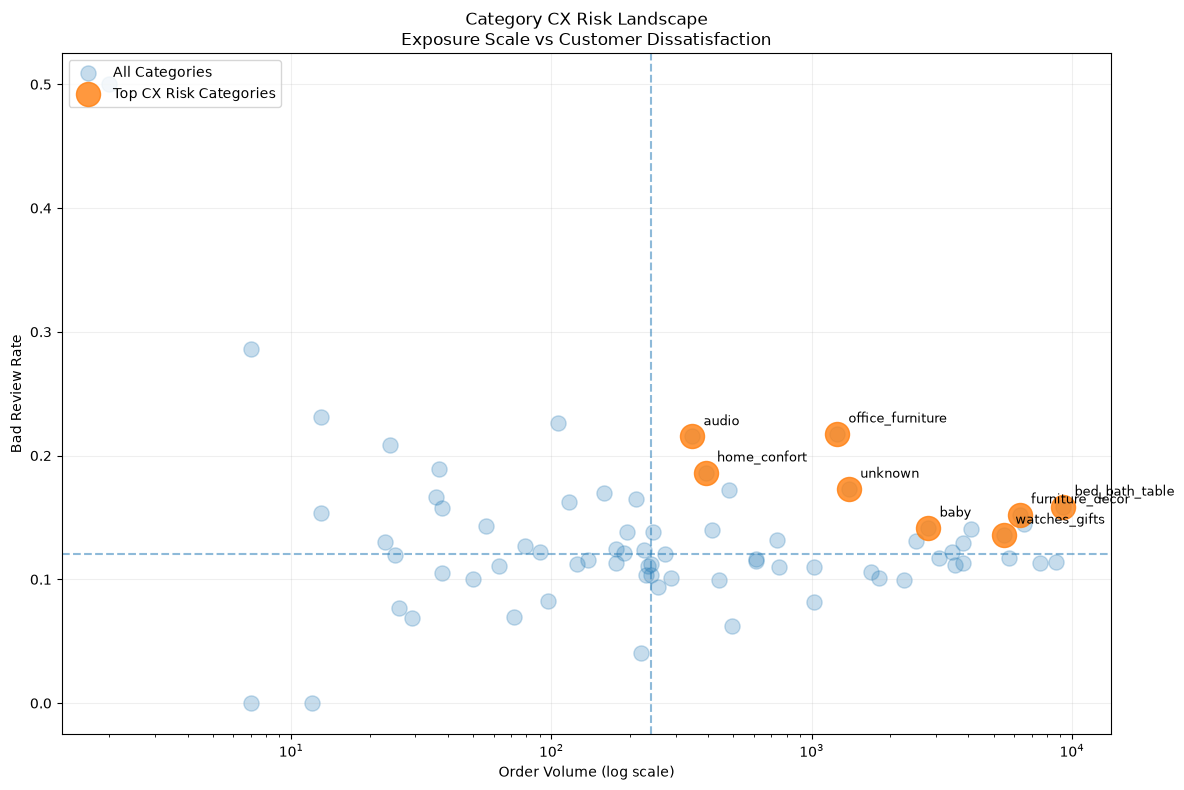

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------
# Prepare Data
# ---------------------------------------

category_plot = category_risk.copy()


category_plot = category_plot[
    category_plot["order_count"] > 0
]


# Select important categories

top_categories = (
    category_plot
    .sort_values(
        "cx_risk_score",
        ascending=False
    )
    .head(8)
)


# ---------------------------------------
# Create Figure
# ---------------------------------------

plt.figure(figsize=(12,8))


# ---------------------------------------
# Plot all categories
# ---------------------------------------

plt.scatter(
    category_plot["order_count"],
    category_plot["bad_review_rate"],
    s=120,
    alpha=0.25,
    label="All Categories"
)



# ---------------------------------------
# Highlight priority categories
# ---------------------------------------

plt.scatter(
    top_categories["order_count"],
    top_categories["bad_review_rate"],
    s=300,
    alpha=0.8,
    label="Top CX Risk Categories"
)



# ---------------------------------------
# Labels only important categories
# ---------------------------------------

for i, row in top_categories.iterrows():

    plt.annotate(
        row["product_category_clean"],
        (
            row["order_count"],
            row["bad_review_rate"]
        ),
        xytext=(8,8),
        textcoords="offset points",
        fontsize=9
    )



# ---------------------------------------
# Median reference lines
# ---------------------------------------

plt.axvline(
    category_plot["order_count"].median(),
    linestyle="--",
    alpha=0.5
)


plt.axhline(
    category_plot["bad_review_rate"].median(),
    linestyle="--",
    alpha=0.5
)



# ---------------------------------------
# Log scale
# ---------------------------------------

plt.xscale("log")



# ---------------------------------------
# Formatting
# ---------------------------------------

plt.xlabel(
    "Order Volume (log scale)"
)


plt.ylabel(
    "Bad Review Rate"
)


plt.title(
    "Category CX Risk Landscape\n"
    "Exposure Scale vs Customer Dissatisfaction"
)


plt.legend(
    loc="upper left"
)


plt.grid(
    alpha=0.2
)


plt.tight_layout()


plt.show()



Contribution vs Severity Matrix
解释：

X:

How much business exposure?
Y:

How severe is CX failure?
Bubble:

Overall CX risk score


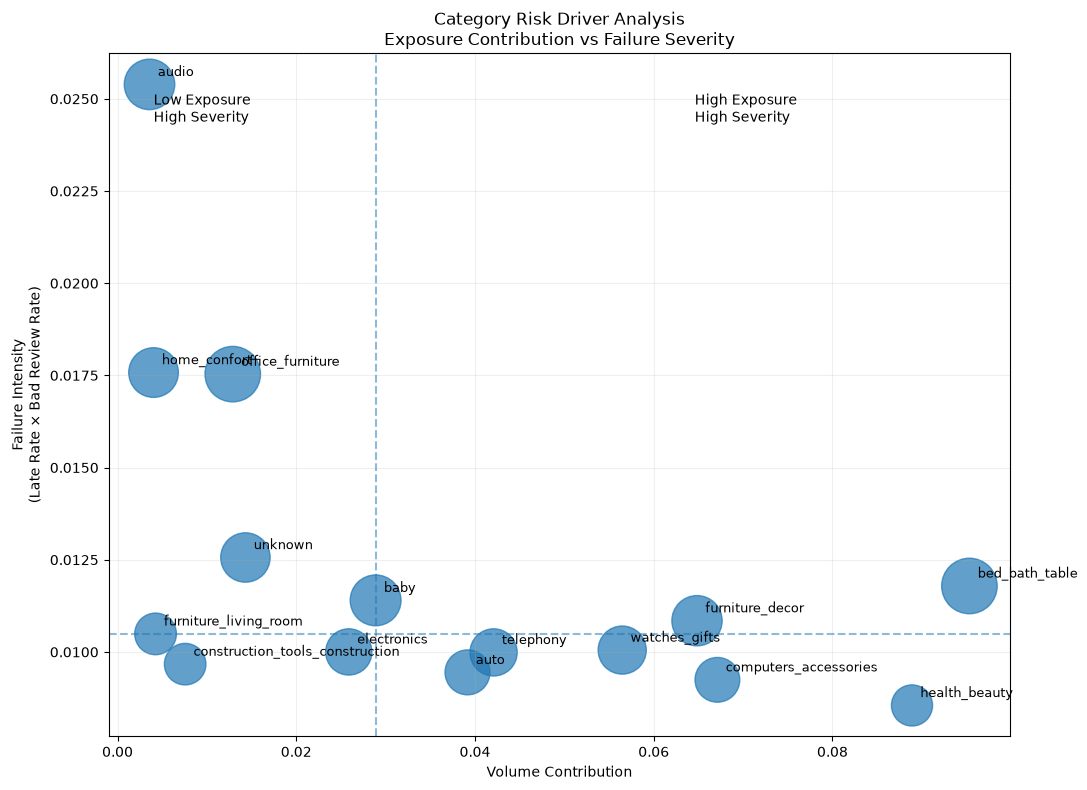

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------
# Prepare data
# ---------------------------------------

category_driver = category_risk.copy()



# Exposure contribution

category_driver["volume_share"] = (
    category_driver["order_count"]
    /
    category_driver["order_count"].sum()
)



# Failure intensity

category_driver["failure_intensity"] = (
    category_driver["late_rate"]
    *
    category_driver["bad_review_rate"]
)



# Select top categories

category_driver = (
    category_driver
    .sort_values(
        "cx_risk_score",
        ascending=False
    )
    .head(15)
)



# ---------------------------------------
# Plot
# ---------------------------------------

plt.figure(figsize=(11,8))



# Bubble size

bubble_size = (
    category_driver["cx_risk_score"]
    /
    category_driver["cx_risk_score"].max()
    *
    1500
    +
    100
)



plt.scatter(
    category_driver["volume_share"],
    category_driver["failure_intensity"],
    s=bubble_size,
    alpha=0.7,
    label="Category"
)



# ---------------------------------------
# Labels
# ---------------------------------------

for _, row in category_driver.iterrows():

    plt.annotate(
        row["product_category_clean"],
        (
            row["volume_share"],
            row["failure_intensity"]
        ),
        xytext=(6,6),
        textcoords="offset points",
        fontsize=9
    )



# ---------------------------------------
# Median lines
# ---------------------------------------

plt.axvline(
    category_driver["volume_share"].median(),
    linestyle="--",
    alpha=0.5
)


plt.axhline(
    category_driver["failure_intensity"].median(),
    linestyle="--",
    alpha=0.5
)



# ---------------------------------------
# Quadrant explanation
# ---------------------------------------

plt.text(
    0.65,
    0.9,
    "High Exposure\nHigh Severity",
    transform=plt.gca().transAxes,
    fontsize=10
)


plt.text(
    0.05,
    0.9,
    "Low Exposure\nHigh Severity",
    transform=plt.gca().transAxes,
    fontsize=10
)



# ---------------------------------------
# Formatting
# ---------------------------------------

plt.xlabel(
    "Volume Contribution"
)


plt.ylabel(
    "Failure Intensity\n(Late Rate × Bad Review Rate)"
)


plt.title(
    "Category Risk Driver Analysis\n"
    "Exposure Contribution vs Failure Severity"
)


plt.grid(
    alpha=0.2
)


plt.tight_layout()


plt.show()


# Category Risk Interpretation


## Objective


Identify whether category-level customer experience risk is primarily driven by:

1. Customer exposure scale
2. Failure intensity


Category risk should not be evaluated only by ranking categories,
because different categories may create customer impact through different mechanisms.


The analysis therefore combines:

- Category CX Risk Landscape:
    identifying where risk exposure is concentrated

- Category Risk Driver Analysis:
    separating exposure contribution from failure severity


---

# Key Findings


## 1. Exposure Scale: Categories Affecting a Larger Customer Population


The Category CX Risk Landscape shows that some categories generate higher CX exposure
because they represent a larger share of customer orders.


For example, categories such as:

- bed_bath_table
- furniture_decor
- watches_gifts


appear on the higher-volume side of the distribution.


These categories may create significant customer impact because even moderate delivery issues
can affect a large number of customers.


This represents an exposure-driven risk pattern:

> High business volume creates higher potential customer impact.


However, high exposure does not necessarily indicate higher operational failure severity.
Further operational data is required to understand whether these issues are caused by:

- product characteristics
- fulfillment complexity
- delivery constraints
- seller performance


---

## 2. Failure Intensity: Categories with Higher Customer Friction


The Category Risk Driver Analysis highlights categories where customer dissatisfaction
is relatively high compared with their contribution to total order volume.


Categories such as:

- audio
- office_furniture
- home_comfort


show higher failure intensity despite lower volume contribution.


This suggests that these categories may experience stronger customer friction,
where a smaller customer population encounters a higher rate of negative experience.


This represents an intensity-driven risk pattern:

> Operational issues may be more severe even when customer exposure is smaller.


---

## 3. Risk Driver Interpretation


The two analyses together show that category risk has different underlying patterns:


### Exposure-driven categories

Characteristics:

- High order contribution
- Moderate dissatisfaction intensity

Potential business concern:

A small improvement in reliability may affect a large number of customers.


---

### Severity-driven categories

Characteristics:

- Lower order contribution
- Higher dissatisfaction intensity

Potential business concern:

The customer experience issue may require deeper investigation,
because failure rates appear elevated relative to category size.


---

## Analytical Limitations


The current analysis identifies category-level CX exposure and failure patterns,
but it cannot determine operational root causes.


The dataset does not include:

- product dimensions
- product weight
- packaging requirements
- delivery expectation
- return reasons
- customer service interactions


Therefore, category risk should be interpreted as a prioritisation framework
rather than a confirmed explanation of why customer dissatisfaction occurs.


---

## Recommended Next Investigation


Future analysis should examine:

- whether high-risk categories are concentrated among specific sellers
- whether product characteristics increase delivery difficulty
- whether certain categories have different customer expectations
- whether return and support behaviour differs across categories




# 3. Regional Delivery Reliability

## Why

Delivery problems may be caused by network lanes rather than individual sellers.

Seller → customer state relationships reveal geographic reliability patterns.


In [ ]:

region_risk["risk_score"] = (
    region_risk["order_count"].rank(pct=True)
    *
    region_risk["late_rate"].rank(pct=True)
    *
    region_risk["bad_review_rate"].rank(pct=True)
)

region_risk.sort_values(
    "risk_score",
    ascending=False
).head(10)


,seller_state,customer_state,order_count,late_rate,avg_delay_days,bad_review_rate,risk_exposure,risk_score
386,SP,AL,256,0.237354,-7.961089,0.241245,60.762646,0.721300
394,SP,MA,493,0.189135,-9.303823,0.225352,93.243461,0.718928
403,SP,RJ,8188,0.139836,-10.918419,0.204133,1144.974136,0.697356
409,SP,SE,208,0.161905,-9.466667,0.204762,33.676190,0.647814
389,SP,BA,2313,0.126923,-10.857265,0.185043,293.573077,0.640119
271,PR,RJ,978,0.118902,-13.329268,0.205285,116.286585,0.639381
254,PR,AL,36,0.305556,-6.138889,0.333333,11.000000,0.637235
142,MA,SP,124,0.201613,-9.959677,0.185484,25.000000,0.623658
285,RJ,CE,54,0.203704,-6.425926,0.240741,11.000000,0.614052
401,SP,PI,329,0.163142,-10.607251,0.169184,53.673716,0.608346


找：origin → destination

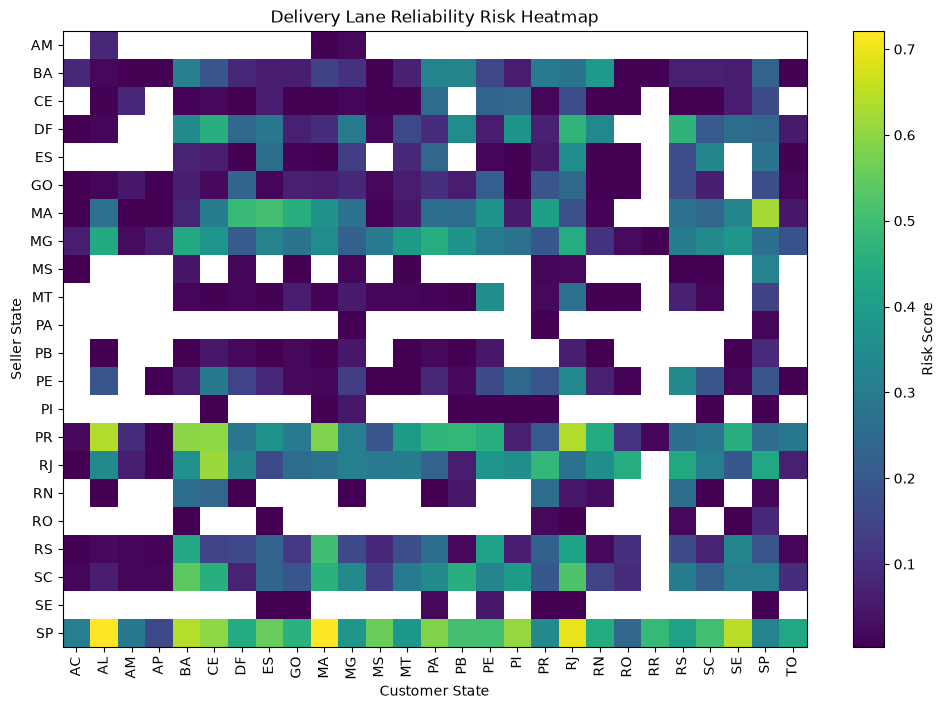

In [ ]:
import matplotlib.pyplot as plt


lane_matrix = (
    region_risk
    .pivot_table(
        index="seller_state",
        columns="customer_state",
        values="risk_score",
        aggfunc="mean"
    )
)



plt.figure(figsize=(12,8))


plt.imshow(
    lane_matrix,
    aspect="auto"
)


plt.colorbar(
    label="Risk Score"
)


plt.xticks(
    range(len(lane_matrix.columns)),
    lane_matrix.columns,
    rotation=90
)


plt.yticks(
    range(len(lane_matrix.index)),
    lane_matrix.index
)


plt.xlabel(
    "Customer State"
)


plt.ylabel(
    "Seller State"
)


plt.title(
    "Delivery Lane Reliability Risk Heatmap"
)


plt.show()


High Exposure Lane Analysis
做：risk_score + order volume
Service Reliability Planning：


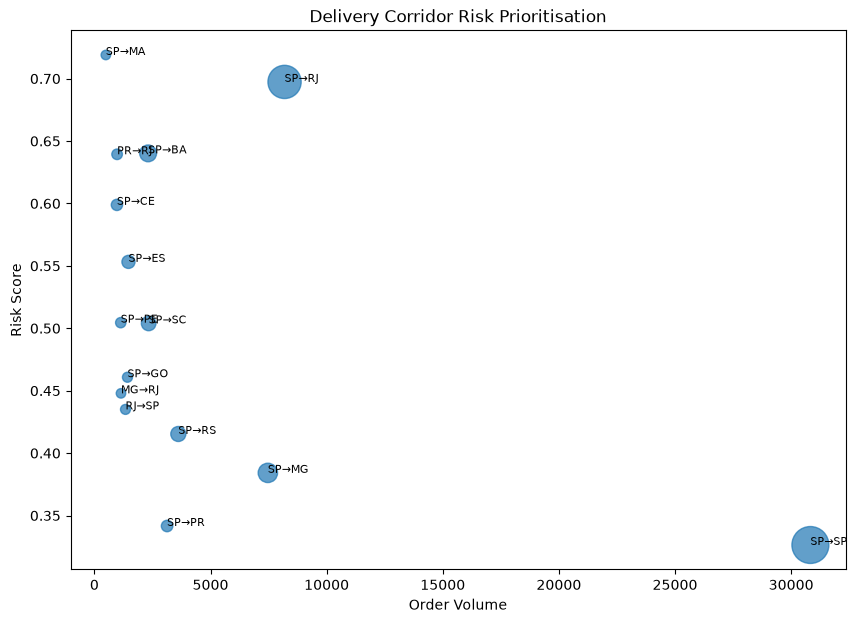

In [ ]:
lane_priority = (
    region_risk
    .copy()
)


lane_priority = (
    lane_priority
    .sort_values(
        "risk_exposure",
        ascending=False
    )
    .head(15)
)



plt.figure(figsize=(10,7))


plt.scatter(
    lane_priority["order_count"],
    lane_priority["risk_score"],
    s=lane_priority["risk_exposure"]/2,
    alpha=0.7
)



for _,row in lane_priority.iterrows():

    plt.text(
        row["order_count"],
        row["risk_score"],
        row["seller_state"]
        +
        "→"
        +
        row["customer_state"],
        fontsize=8
    )



plt.xlabel(
    "Order Volume"
)


plt.ylabel(
    "Risk Score"
)


plt.title(
    "Delivery Corridor Risk Prioritisation"
)


plt.show()


# Regional Reliability Interpretation


## Objective


Identify delivery corridors where customer exposure and reliability risk are concentrated.


Regional analysis focuses on delivery lane performance:

Seller location → Customer location


rather than isolated state-level performance.


---

## Key Findings


The corridor analysis highlights that delivery risk varies significantly across routes.


High-risk corridors may appear due to different combinations of:

- large shipment volume
- elevated late delivery rates
- higher customer dissatisfaction


For example, some routes show both meaningful order exposure and elevated risk scores,
making them potential priorities for further operational investigation.


---

## Delivery Corridor Prioritisation


The corridor prioritisation framework separates:

### High Volume + High Risk Corridors

Potential areas where reliability improvements could affect a large customer population.


### Low Volume + High Risk Corridors

Potential investigation areas where operational issues appear severe,
although customer exposure is smaller.


### High Volume + Lower Risk Corridors

Important service corridors that should maintain current reliability levels.


---

## Analytical Limitations


The current dataset identifies where delivery reliability problems are observed,
but cannot determine the underlying logistics cause.


Missing operational variables include:

- shipping distance
- carrier information
- transportation mode
- delivery attempts
- warehouse location


Therefore, high-risk lanes should be interpreted as investigation priorities
rather than confirmed logistics root causes.


---

## Additional Data Required


Additional operational data would help distinguish between:

- geographic distance effects
- carrier performance issues
- fulfillment constraints
- regional capacity limitations
- transportation network inefficiencies



# 4. Business Interpretation

Expected outputs:

## Seller Governance

Identify sellers where customer exposure is concentrated.

## Category Monitoring

Identify categories where delivery problems create disproportionate CX impact.

## Service Reliability Planning

Identify delivery corridors requiring logistics attention.

The final objective is moving from:

Operational measurement

to

Decision support.


In [ ]:

# Export enhanced analytical tables

seller_risk.to_csv(
    "../outputs/tables/seller_risk_segmentation_v3.csv",
    index=False
)

category_risk.to_csv(
    "../outputs/tables/category_risk_segmentation_v3.csv",
    index=False
)

region_risk.to_csv(
    "../outputs/tables/region_risk_segmentation_v3.csv",
    index=False
)


# Executive Summary


This analysis identifies where customer experience risk is concentrated across:

1. Sellers
2. Product categories
3. Delivery corridors


Key observations:

- CX risk exposure is concentrated among a smaller group of sellers.
- Category risk is driven by both customer exposure scale and failure intensity.
- Certain delivery corridors show elevated reliability risk and require further investigation.


The current analysis provides prioritisation signals,
but additional operational data is required before defining root causes or interventions.


Recommended next steps:

1. Enrich seller analysis with operational performance data.
2. Add logistics attributes for corridor diagnosis.
3. Incorporate customer behaviour data to estimate true business impact.
